Project 3 Details: 
 <br>
1. Defining the problem: For each recording, the raw signal in different states are provided separately. You need to preprocess the raw data and create your own input data and output labels for the two states. You need to cut the recording into small clips of certain fixed length (e.g. 5 seconds). Each clip will be a data sample and corresponds to a label of state.
2. Designing model inputs: You can try using directly the raw signal as input or you can apply techniques you learned from signal processing to extract features from the raw signal and use the extracted features as input. The prediction gets more difficult (i.e. lower accuracy) as the length of a clip gets shorter (meaning higher time resolution in predicting the state). Hints for extracting input features:
* Calculate statistics of each clip, e.g. mean, standard deviation, skewness, kurtosis, etc.
* Calculate the PSD of each clip with low frequency resolution (i.e. using small length of segment for PSD estimation, a fraction of the clip length).
* Find oscillation frequency bands (bumps) in the overall PSD of each state. Bandpass filter the signal within the frequency bands and get the statistics of each clip in that band (e.g. signal power within the band).
* Perform normalization (z-score or min-max) to scale the magnitude of input features.
3. Train different network models for different subjects. But it's good to develop a general algorithm, i.e. using the same data processing scheme, same network architecture and hyperparameters, while the trained parameters in models for different subjects are distinct.
4. You are to explore methods in signal processing, feature engineering, network architectures, etc., to improve the performance and test the limits of your models. Also note all the issues you encountered when you develop the model, and state how you have solved them (not the technical issues like coding, but the issues related to machine learning).
 <br>
 <br>
 Methodology:
 <br>
Raw LFP → segment into clips → extract features → normalize → FCNN → classify (NREM vs WAKE)

In [22]:
# Import packages
import h5py
import numpy as np
import torch 
import matplotlib.pyplot as plt

Firstly, we need to load in the data files and look at them.

Keys/datasets in the file:
* NREM (Type: Group)
* WAKE (Type: Group)


Sampling rate: 1000.0 Hz
State: NREM
Segment IDs:
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '3', '4', '5', '6', '7', '8', '9']
State: WAKE
Segment IDs:
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9']


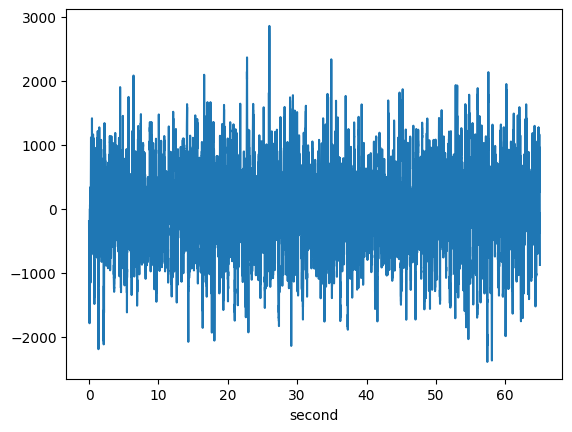

In [24]:
# Filepaths
file1 = 'Project3_LFP_data/Part1SubjectHB10.h5'
file2 = 'Project3_LFP_data/Part2SubjectHB13.h5'
file3 = 'Project3_LFP_data/Rat08-20130711_017.h5'

filename = file2

try:
    with h5py.File(filename, "r") as h5f:
        print("Keys/datasets in the file:")
        for key in h5f.keys():
            print(f"* {key} (Type: {h5f[key].__class__.__name__})")

            # If it's a dataset, you can access its properties (shape, dtype)
            if isinstance(h5f[key], h5py.Dataset):
                dataset = h5f[key]
                print(f"  Shape: {dataset.shape}, Data Type: {dataset.dtype}")
                # To read the data into a NumPy array (caution with large files)
                # data = dataset[:] 

except IOError:
    print(f"Error opening file: {filename}. Check the file path.")
    
print("\n")

### BELOW IS TAKEN FROM THE lfp_state_classification_read_data.ipynb NOTEBOOK ###

f = h5py.File(filename, 'r')  # read data with h5 format
fs = f.attrs['fs'][0]  # get sampling frequency of LFP signal (Hz)
print("Sampling rate: %.1f Hz" % (fs))

states = []  # two states (NREM & WAKE) to be classified
# LFP recordings are store in two h5 groups for each state
# Under each h5 group, the LFP recordings are divided into several segments with different lengths.
for name, grp in f.items():
  states.append(name)
  print("State: %s" % (name))
  print("Segment IDs:")
  print(list(grp.keys()))
  
  # Convert the recording in to numpy arrays
# Use a dictionary to store the LFP recordings of the two states
# each containing a list of numpy arrays of all segments
lfp = {key: [] for key in states}  
for key in states:
  group = f[key]  # h5 group of a state
  n = len(group)  # number of segments
  for i in range(n):
    lfp[key].append(group[str(i+1)][()].astype(float))  # convert data to numpy array and from int type to float type

# print(lfp)

x = lfp['NREM'][10]  # accessing the 10-th LFP segment in NREM state
t = np.arange(x.size)/fs  # time points

plt.plot(t,x)
plt.xlabel('second')
plt.show()

Now that we visualized it, we can load in data

In [25]:
import h5py
import numpy as np

def load_lfp_file(filepath):
    with h5py.File(filepath, 'r') as f:
        nrem_segments = []
        wake_segments = []
        
        # Load NREM
        for key in f['NREM'].keys():
            nrem_segments.append(np.array(f['NREM'][key]))
        
        # Load WAKE
        for key in f['WAKE'].keys():
            wake_segments.append(np.array(f['WAKE'][key]))
    
    return nrem_segments, wake_segments

1. Preprocess: Segment the signal into clips

In [26]:
def segment_to_clips(segment, fs=1000, clip_len=5):
    samples_per_clip = fs * clip_len
    num_clips = len(segment) // samples_per_clip
    
    clips = []
    for i in range(num_clips):
        start = i * samples_per_clip
        end = start + samples_per_clip
        clips.append(segment[start:end])
    
    return clips

2. Feature Engineering (IMPORTANT for FCN)

In [30]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

def extract_features(clip, fs=1000):
    features = []
    
    # Time-domain
    features.append(np.mean(clip))
    features.append(np.std(clip))
    features.append(skew(clip))
    features.append(kurtosis(clip))
    
    # Frequency-domain (VERY important for brain states)
    freqs, psd = welch(clip, fs=fs, nperseg=fs)
    
    def band_power(fmin, fmax):
        mask = (freqs >= fmin) & (freqs <= fmax)
        return np.sum(psd[mask])
    
    # Key brain bands
    features.append(band_power(0.5, 4))    # Delta (strong in NREM)
    features.append(band_power(4, 8))      # Theta
    features.append(band_power(8, 12))     # Alpha
    features.append(band_power(12, 30))    # Beta
    
    return np.array(features)

3. Build Dataset Pipeline

In [31]:
def build_dataset(filepath):
    nrem_segments, wake_segments = load_lfp_file(filepath)
    
    X = []
    y = []
    
    # NREM = 0
    for seg in nrem_segments:
        clips = segment_to_clips(seg)
        for clip in clips:
            X.append(extract_features(clip))
            y.append(0)
    
    # WAKE = 1
    for seg in wake_segments:
        clips = segment_to_clips(seg)
        for clip in clips:
            X.append(extract_features(clip))
            y.append(1)
    
    return np.array(X), np.array(y)

4. Normalize Features

In [32]:
from sklearn.preprocessing import StandardScaler

X, y = build_dataset(file1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

6. Fully Connected Neural Network (FCN) PyTorch Model

In [33]:
import torch
import torch.nn as nn

class FCNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        return self.net(x)

7. Training Setup

In [39]:
from torch.utils.data import Dataset, DataLoader

class LFPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = LFPDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = FCNN(input_dim=X.shape[1])

8. Training Loop

In [41]:
def train_model(model, loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        losses.append(total_loss)
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    
    return losses

Epoch 1, Loss: 17.4053
Epoch 2, Loss: 9.3427
Epoch 3, Loss: 4.1323
Epoch 4, Loss: 2.1189
Epoch 5, Loss: 1.3308
Epoch 6, Loss: 0.9826
Epoch 7, Loss: 0.6308
Epoch 8, Loss: 0.6796
Epoch 9, Loss: 0.4879
Epoch 10, Loss: 0.5165
Epoch 11, Loss: 0.4593
Epoch 12, Loss: 0.2804
Epoch 13, Loss: 0.5920
Epoch 14, Loss: 0.4050
Epoch 15, Loss: 0.2888
Epoch 16, Loss: 0.2943
Epoch 17, Loss: 0.2271
Epoch 18, Loss: 0.1863
Epoch 19, Loss: 0.2974
Epoch 20, Loss: 0.1706


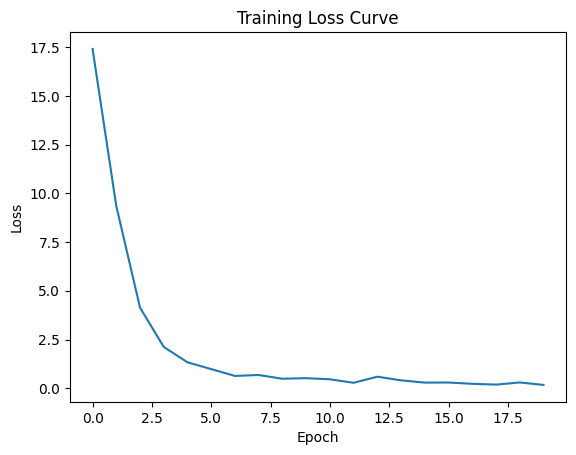

In [42]:
losses = train_model(model, loader)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

Confusion Matrix:

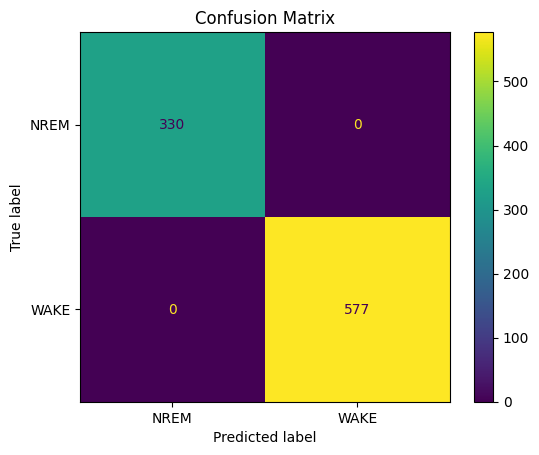

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            preds = torch.argmax(outputs, dim=1)
            
            y_true.extend(yb.numpy())
            y_pred.extend(preds.numpy())
    
    return y_true, y_pred

y_true, y_pred = evaluate(model, loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NREM", "WAKE"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Conclusion: In this project, a Fully Connected Neural Network (FCNN) was developed to classify local field potential (LFP) signals into two brain states: NREM and WAKE. The raw electrophysiological signals were first segmented into fixed-length clips, allowing the continuous recordings to be transformed into labeled samples suitable for supervised learning. Rather than using raw time-series data directly, a feature engineering approach was applied to extract meaningful statistical and frequency-domain characteristics from each clip, including measures such as mean, standard deviation, skewness, kurtosis, and band-specific power derived from power spectral density (PSD) analysis.